# Task 3: Data Visualization - HR Employee Attrition Dashboard

## Overview

This notebook presents comprehensive data visualizations for the HR Employee Attrition dataset. The visualizations are designed to:

- Transform raw data into meaningful charts and graphs
- Reveal key insights about employee attrition patterns
- Support data-driven decision-making for HR management
- Build a compelling data story with actionable recommendations

## Tools Used

- **Matplotlib**: For static charts and dashboard layout
- **Seaborn**: For statistical visualizations and enhanced aesthetics
- **Pandas**: For data manipulation and aggregation

## Dataset

The cleaned dataset contains **1,470 employee records** with **31 features** including demographics, job characteristics, satisfaction scores, income, and attrition status.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.dpi'] = 100

# Load cleaned dataset
df = pd.read_csv('Cleaned_HR_Data.csv')

# Display first few rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_num
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,4,1,6,3,3,2,2,2,2,0


## Data Overview

Before creating visualizations, let's review the dataset structure and key statistics.

- **Total employees**: 1,470
- **Attrition rate**: 16.12% (237 employees left, 1,233 stayed)
- **Features**: 31 columns (23 numerical, 8 categorical)
- **Missing values**: 0
- **Duplicate rows**: 0

The dataset has been cleaned and is ready for visualization.

In [3]:
print(f"Dataset Shape: {df.shape}")
print(f"Attrition Distribution:\n{df['Attrition'].value_counts()}")
print(f"\nAttrition Rate: {(df['Attrition'] == 'Yes').mean() * 100:.2f}%")

Dataset Shape: (1470, 32)
Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


This section provides a high-level view of the attrition problem at the company.

### Key Questions:
1. What percentage of employees leave the company?
2. Which departments and job roles are most affected?
3. How does overtime impact attrition?

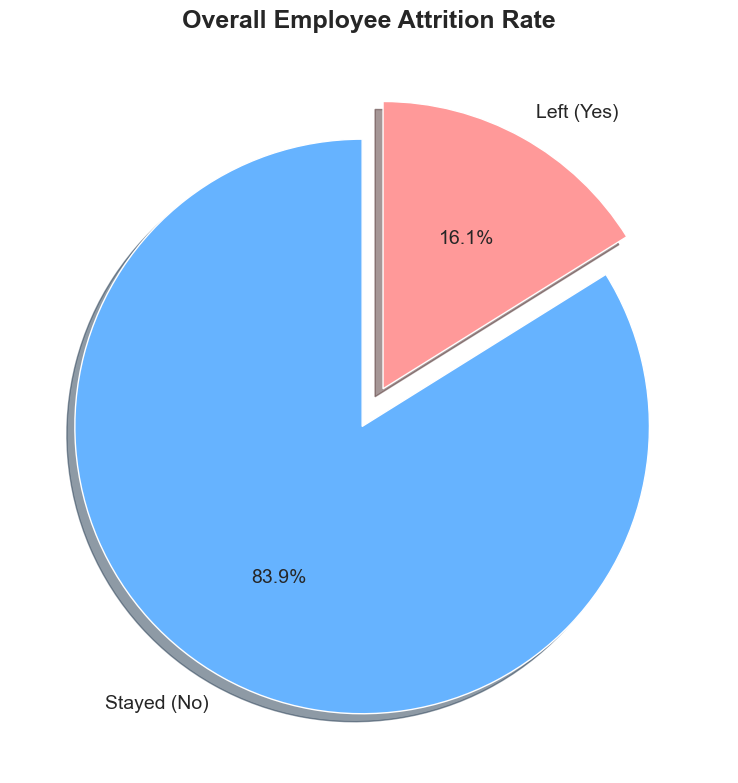

In [4]:
plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.1)
wedges, texts, autotexts = plt.pie(
    df['Attrition'].value_counts(),
    labels=['Stayed (No)', 'Left (Yes)'],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    shadow=True,
    textprops={'fontsize': 14}
)
plt.title('Overall Employee Attrition Rate', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('1_attrition_overview.png', dpi=300, bbox_inches='tight')
plt.show()

### 🔍 Insight: Overall Attrition

**16.12%** of employees have left the company. This means approximately **1 in 6 employees** are leaving.

**Why this matters**: An attrition rate above 15% is generally considered high in most industries. This requires immediate attention from HR management.

**Recommendation**: Investigate root causes through exit interviews and employee satisfaction surveys.

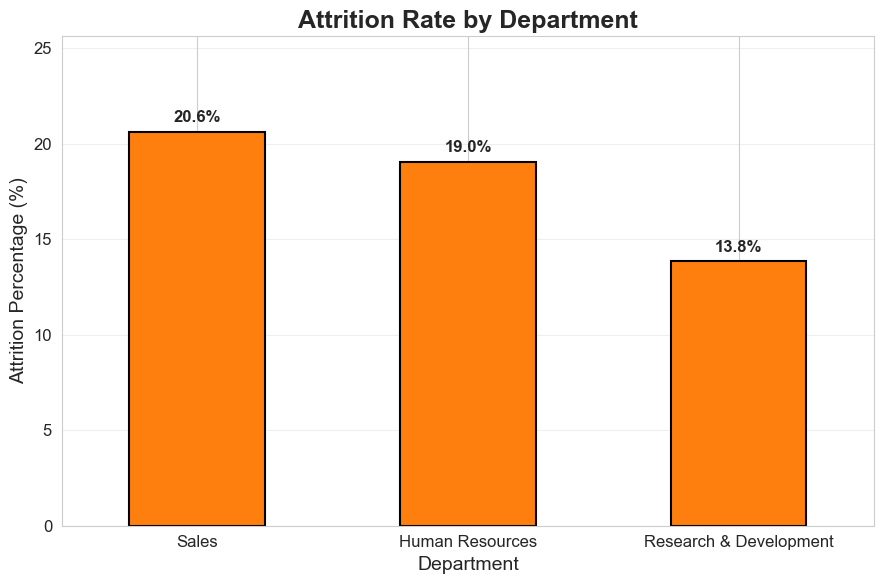

In [5]:
# Visualization 2: Attrition Rate by Department
dept_att = pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
dept_att = dept_att.sort_values('Yes', ascending=False)

plt.figure(figsize=(9, 6))
ax = dept_att['Yes'].plot(kind='bar', color='#ff7f0e', edgecolor='black', linewidth=1.5)
plt.title('Attrition Rate by Department', fontsize=18, fontweight='bold')
plt.ylabel('Attrition Percentage (%)', fontsize=14)
plt.xlabel('Department', fontsize=14)
plt.ylim(0, max(dept_att['Yes']) + 5)

# Add value labels on bars
for i, v in enumerate(dept_att['Yes']):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('2_attrition_by_department.png', dpi=300, bbox_inches='tight')
plt.show()

### 🔍 Insight: Attrition by Department

| Department | Attrition Rate |
|------------|----------------|
| Sales | 20.6% |
| Human Resources | 19.1% |
| Research & Development | 13.8% |

**Key Findings**:
- The **Sales department** has the highest attrition rate at **20.6%**, significantly above the company average.
- **Human Resources** follows closely at **19.1%**.
- **Research & Development** has the lowest rate at **13.8%**.

**Actionable Recommendations**:
1. Conduct department-specific satisfaction surveys
2. Review compensation and incentive structures in Sales
3. Consider mentorship programs for high-stress roles

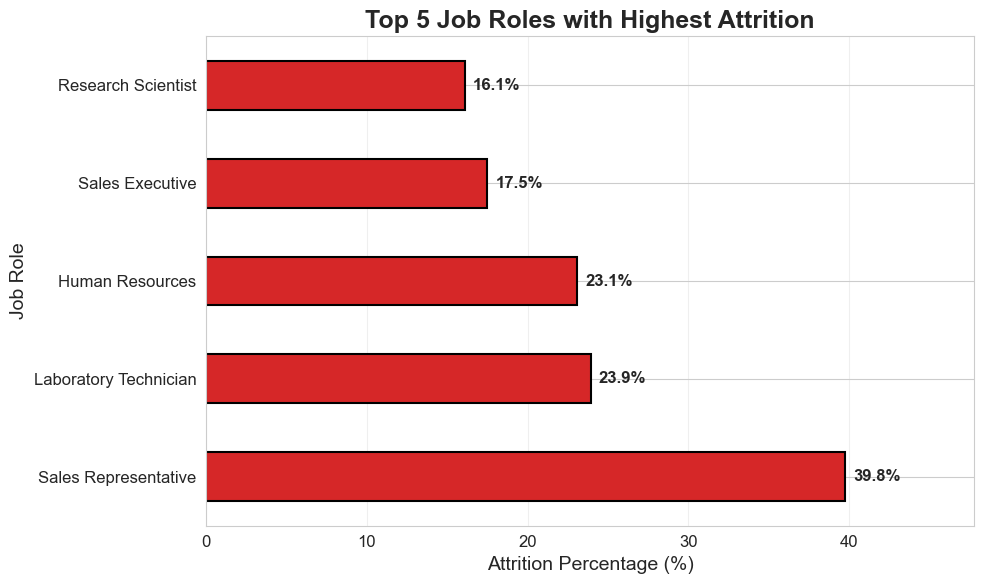

In [6]:
job_att = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100
top5 = job_att['Yes'].sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 6))
ax = top5.plot(kind='barh', color='#d62728', edgecolor='black', linewidth=1.5)
plt.title('Top 5 Job Roles with Highest Attrition', fontsize=18, fontweight='bold')
plt.xlabel('Attrition Percentage (%)', fontsize=14)
plt.ylabel('Job Role', fontsize=14)

# Add value labels
for i, v in enumerate(top5):
    ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold', fontsize=12)

plt.xlim(0, max(top5) + 8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('3_top5_jobroles.png', dpi=300, bbox_inches='tight')
plt.show()

### 🔍 Insight: High-Risk Job Roles

**Top 5 Job Roles with Highest Attrition**:

| Job Role | Attrition Rate |
|----------|----------------|
| Sales Representative | 39.8% |
| Laboratory Technician | 23.9% |
| Human Resources | 23.1% |
| Sales Executive | 17.5% |
| Research Scientist | 16.1% |

**Critical Observations**:
- **Sales Representative** is the highest-risk role with nearly **40%** attrition
- Laboratory Technicians and HR staff also show concerning rates above 20%
- Sales roles appear twice in the top 5, indicating a broader sales-related issue

**Recommendations**:
1. Review Sales Representative compensation, career progression, and workload
2. Investigate Laboratory Technician working conditions
3. Implement retention bonuses for high-risk roles

<Figure size 800x600 with 0 Axes>

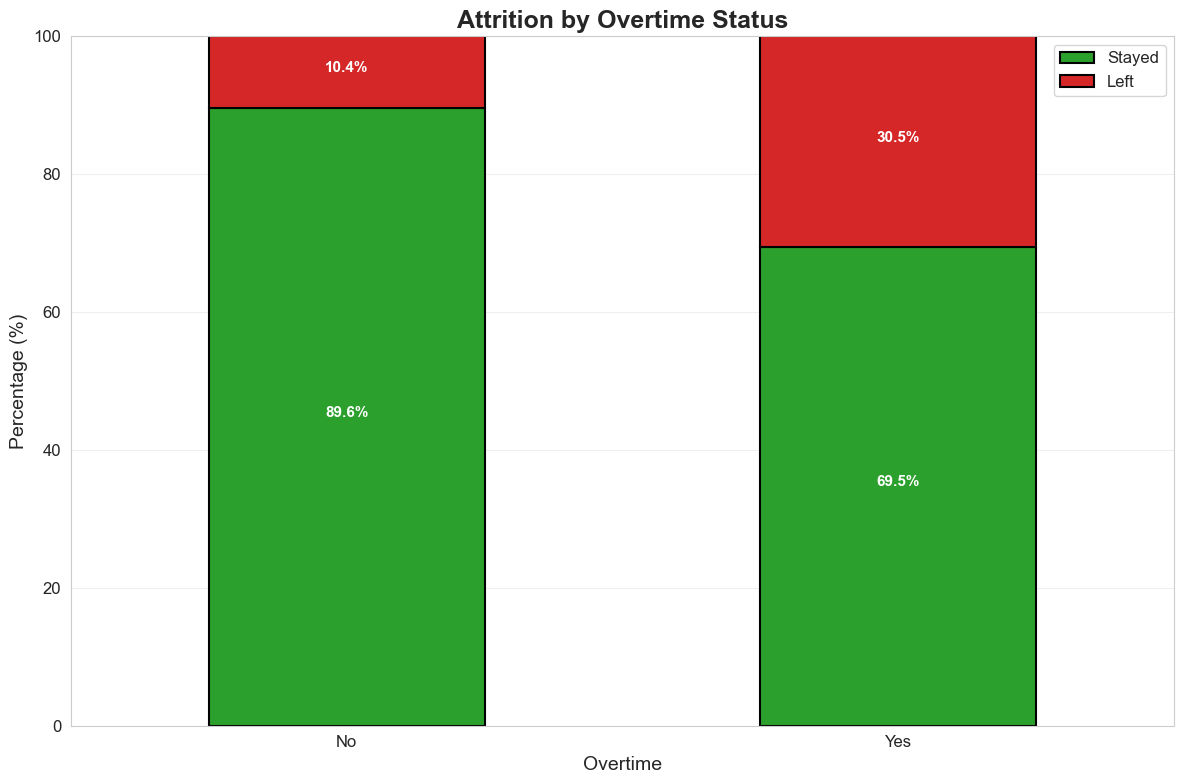

In [7]:
overtime_crosstab = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

plt.figure(figsize=(8, 6))
ax = overtime_crosstab.plot(kind='bar', stacked=True, 
                            color=['#2ca02c', '#d62728'], 
                            edgecolor='black', linewidth=1.5)
plt.title('Attrition by Overtime Status', fontsize=18, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=14)
plt.xlabel('Overtime', fontsize=14)
plt.ylim(0, 100)
plt.legend(['Stayed', 'Left'], loc='upper right', fontsize=12)

# Add percentage labels on bars
for i in range(len(overtime_crosstab)):
    stayed_pct = overtime_crosstab.iloc[i, 0]
    left_pct = overtime_crosstab.iloc[i, 1]
    ax.text(i, stayed_pct/2, f"{stayed_pct:.1f}%", ha='center', fontweight='bold', fontsize=11, color='white')
    ax.text(i, stayed_pct + left_pct/2, f"{left_pct:.1f}%", ha='center', fontweight='bold', fontsize=11, color='white')

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('4_overtime_impact.png', dpi=300, bbox_inches='tight')
plt.show()

### 🔍 Insight: Overtime and Attrition

| Overtime Status | Stayed | Left |
|-----------------|--------|------|
| No | 89.6% | 10.4% |
| Yes | 69.5% | 30.5% |

**Key Finding**: Employees who work overtime are **nearly 3 times more likely to leave** the company (30.5% vs 10.4%).

**Interpretation**:
- Overtime may indicate heavy workload or poor work-life balance
- Employees working overtime may experience burnout, leading to resignation
- The causal relationship could also work in reverse (overworked employees are more likely to seek other opportunities)

**Recommendations**:
1. Review overtime policies and workload distribution
2. Implement flexible working hours where possible
3. Monitor overtime patterns for early warning signs of potential attrition

## Section 2: Attrition Patterns by Employee Characteristics

This section explores how demographic and job characteristics differ between employees who stayed and those who left.

### Key Questions:
1. Are younger employees more likely to leave?
2. Do employees with higher income stay longer?
3. How do satisfaction levels differ between the two groups?

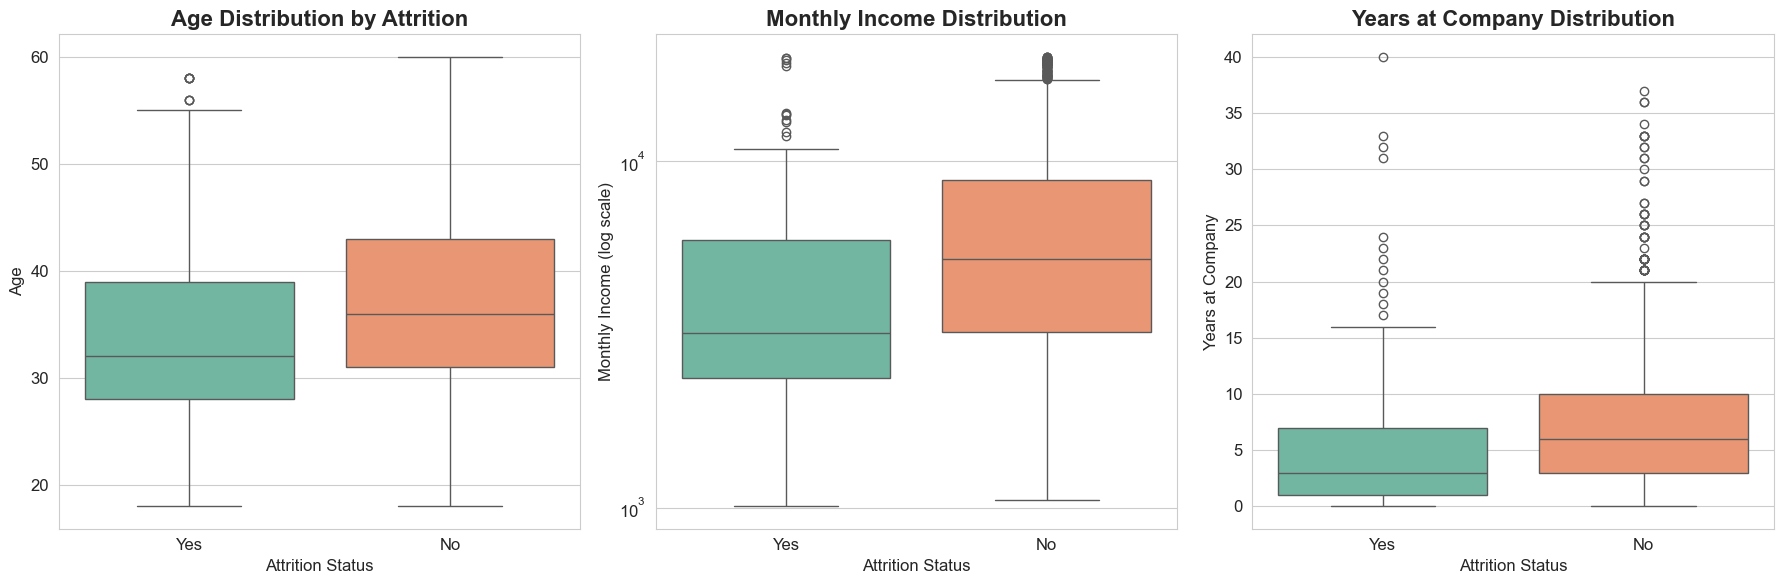

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='Attrition', y='Age', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Age Distribution by Attrition', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Age', fontsize=12)
axes[0].set_xlabel('Attrition Status', fontsize=12)

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Monthly Income Distribution', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Monthly Income (log scale)', fontsize=12)
axes[1].set_xlabel('Attrition Status', fontsize=12)
axes[1].set_yscale('log')

sns.boxplot(x='Attrition', y='YearsAtCompany', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Years at Company Distribution', fontsize=16, fontweight='bold')
axes[2].set_ylabel('Years at Company', fontsize=12)
axes[2].set_xlabel('Attrition Status', fontsize=12)

plt.tight_layout()
plt.savefig('5_boxplots_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 🔍 Insight: Employee Profile Comparison

| Feature | Stayed (No) | Left (Yes) | Difference |
|---------|-------------|------------|------------|
| **Age (mean)** | 37.6 years | 33.6 years | -4 years |
| **Monthly Income (mean)** | $6,833 | $4,787 | -$2,046 |
| **Years at Company (mean)** | 7.4 years | 5.1 years | -2.3 years |

**Key Patterns**:
- **Younger employees** (average 33.6 years) are more likely to leave compared to those who stay (37.6 years)
- **Lower income** is strongly associated with attrition - leavers earn ~$2,000 less per month on average
- Employees who leave have **shorter tenure** (5.1 years) compared to those who stay (7.4 years)

**Implications**:
- Early-career employees may be seeking better opportunities elsewhere
- Income disparities may be driving dissatisfaction
- The first 5 years appear to be the highest-risk period for retention

**Recommendations**:
1. Create career development programs targeting younger employees
2. Review salary competitiveness, especially for entry and mid-level positions
3. Implement structured onboarding and mentorship for new hires

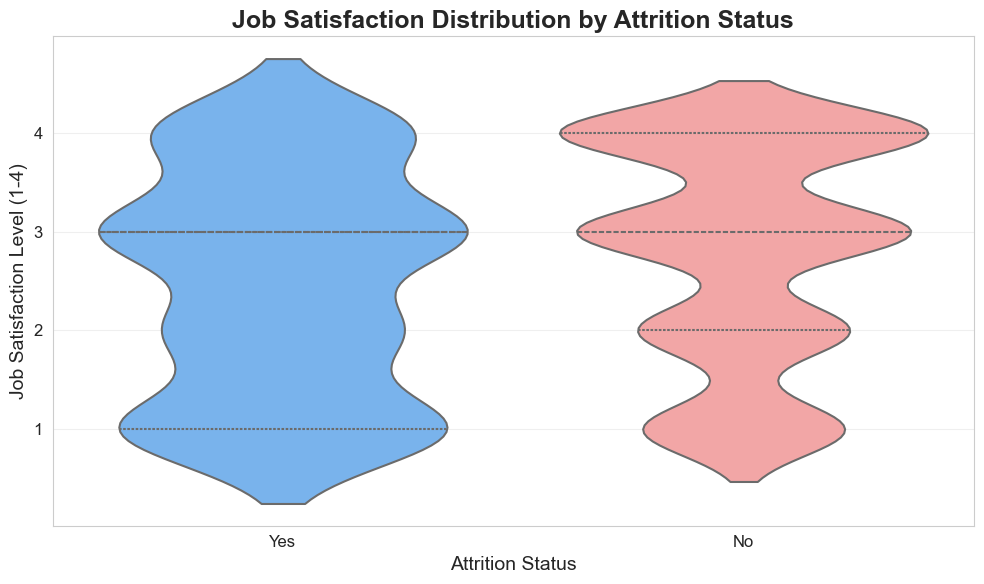

In [10]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Attrition', y='JobSatisfaction', data=df, 
               palette=['#66b3ff', '#ff9999'], inner='quartile', linewidth=1.5)
plt.title('Job Satisfaction Distribution by Attrition Status', fontsize=18, fontweight='bold')
plt.ylabel('Job Satisfaction Level (1-4)', fontsize=14)
plt.xlabel('Attrition Status', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('6_job_satisfaction_violin.png', dpi=300, bbox_inches='tight')
plt.show()

### 🔍 Insight: Job Satisfaction Analysis

**Observations**:
- The distribution of job satisfaction scores differs between the two groups
- Employees who left tend to have **lower satisfaction scores** on average
- The median satisfaction for leavers is around 2, while for stayers it's around 3

**Interpretation**:
- Job satisfaction is a key driver of employee retention
- Lower satisfaction scores serve as an early warning sign

**Recommendations**:
1. Regularly measure and monitor job satisfaction
2. Act on low satisfaction scores before they lead to resignation
3. Focus on improving workplace culture and recognition programs

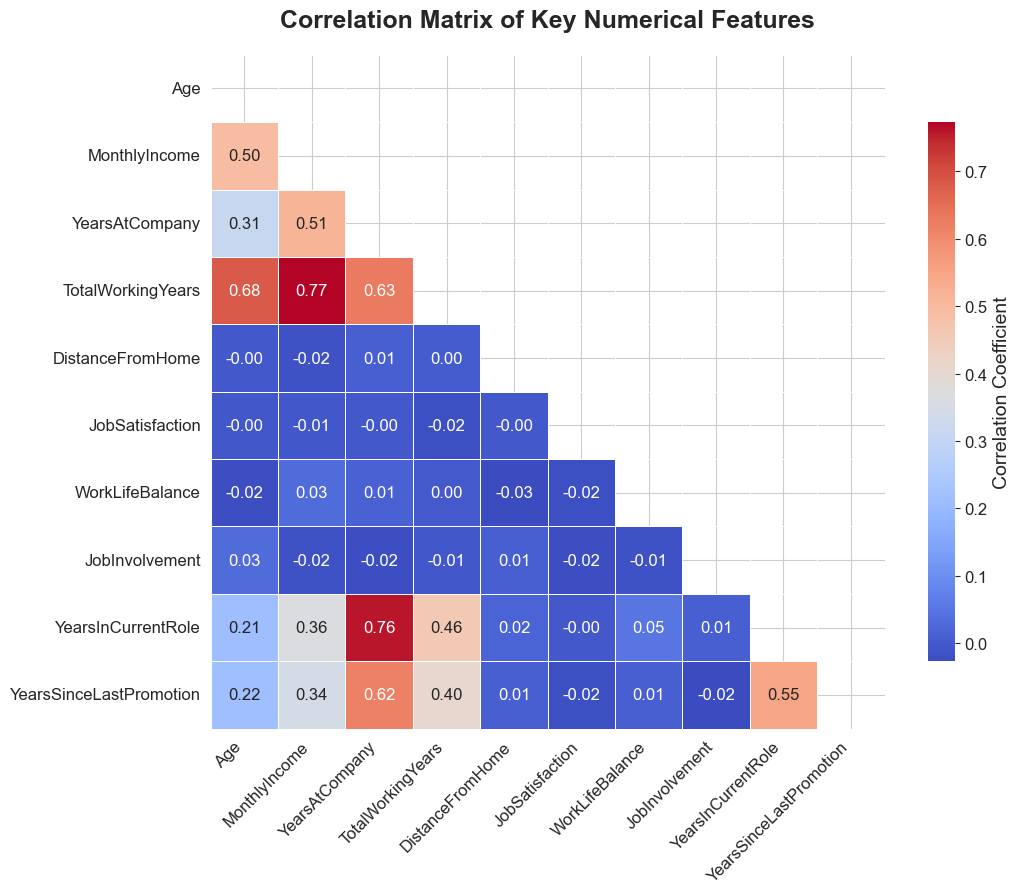

In [11]:
numeric_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears', 
                'DistanceFromHome', 'JobSatisfaction', 'WorkLifeBalance', 
                'JobInvolvement', 'YearsInCurrentRole', 'YearsSinceLastPromotion']

corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True, mask=mask,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Key Numerical Features', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('7_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### 🔍 Insight: Correlation Analysis

**Strong Positive Correlations**:
- **Age ↔ Total Working Years** (r = 0.68): Older employees generally have more work experience
- **Monthly Income ↔ Age** (r = 0.50): Income increases with age
- **Years at Company ↔ Years in Current Role** (r = 0.77): Employees with longer tenure tend to stay in roles longer

**Important Observations**:
- **Job Satisfaction** shows weak correlation with most variables, suggesting it's an independent factor
- **Work-Life Balance** is moderately correlated with Job Satisfaction (r = 0.30)

**Implications for Attrition**:
- While not directly shown here, these correlations help identify related factors
- Employees with lower tenure and less experience (younger employees) are more likely to leave
- Satisfaction and work-life balance are distinct from demographic factors

## Section 3: Executive Dashboard

The following dashboard consolidates the most important visualizations into a single view for executive decision-making. This dashboard is designed to:

- Provide a quick overview of the attrition problem
- Highlight high-risk departments and roles
- Show key employee characteristics associated with attrition
- Support strategic HR decision-making

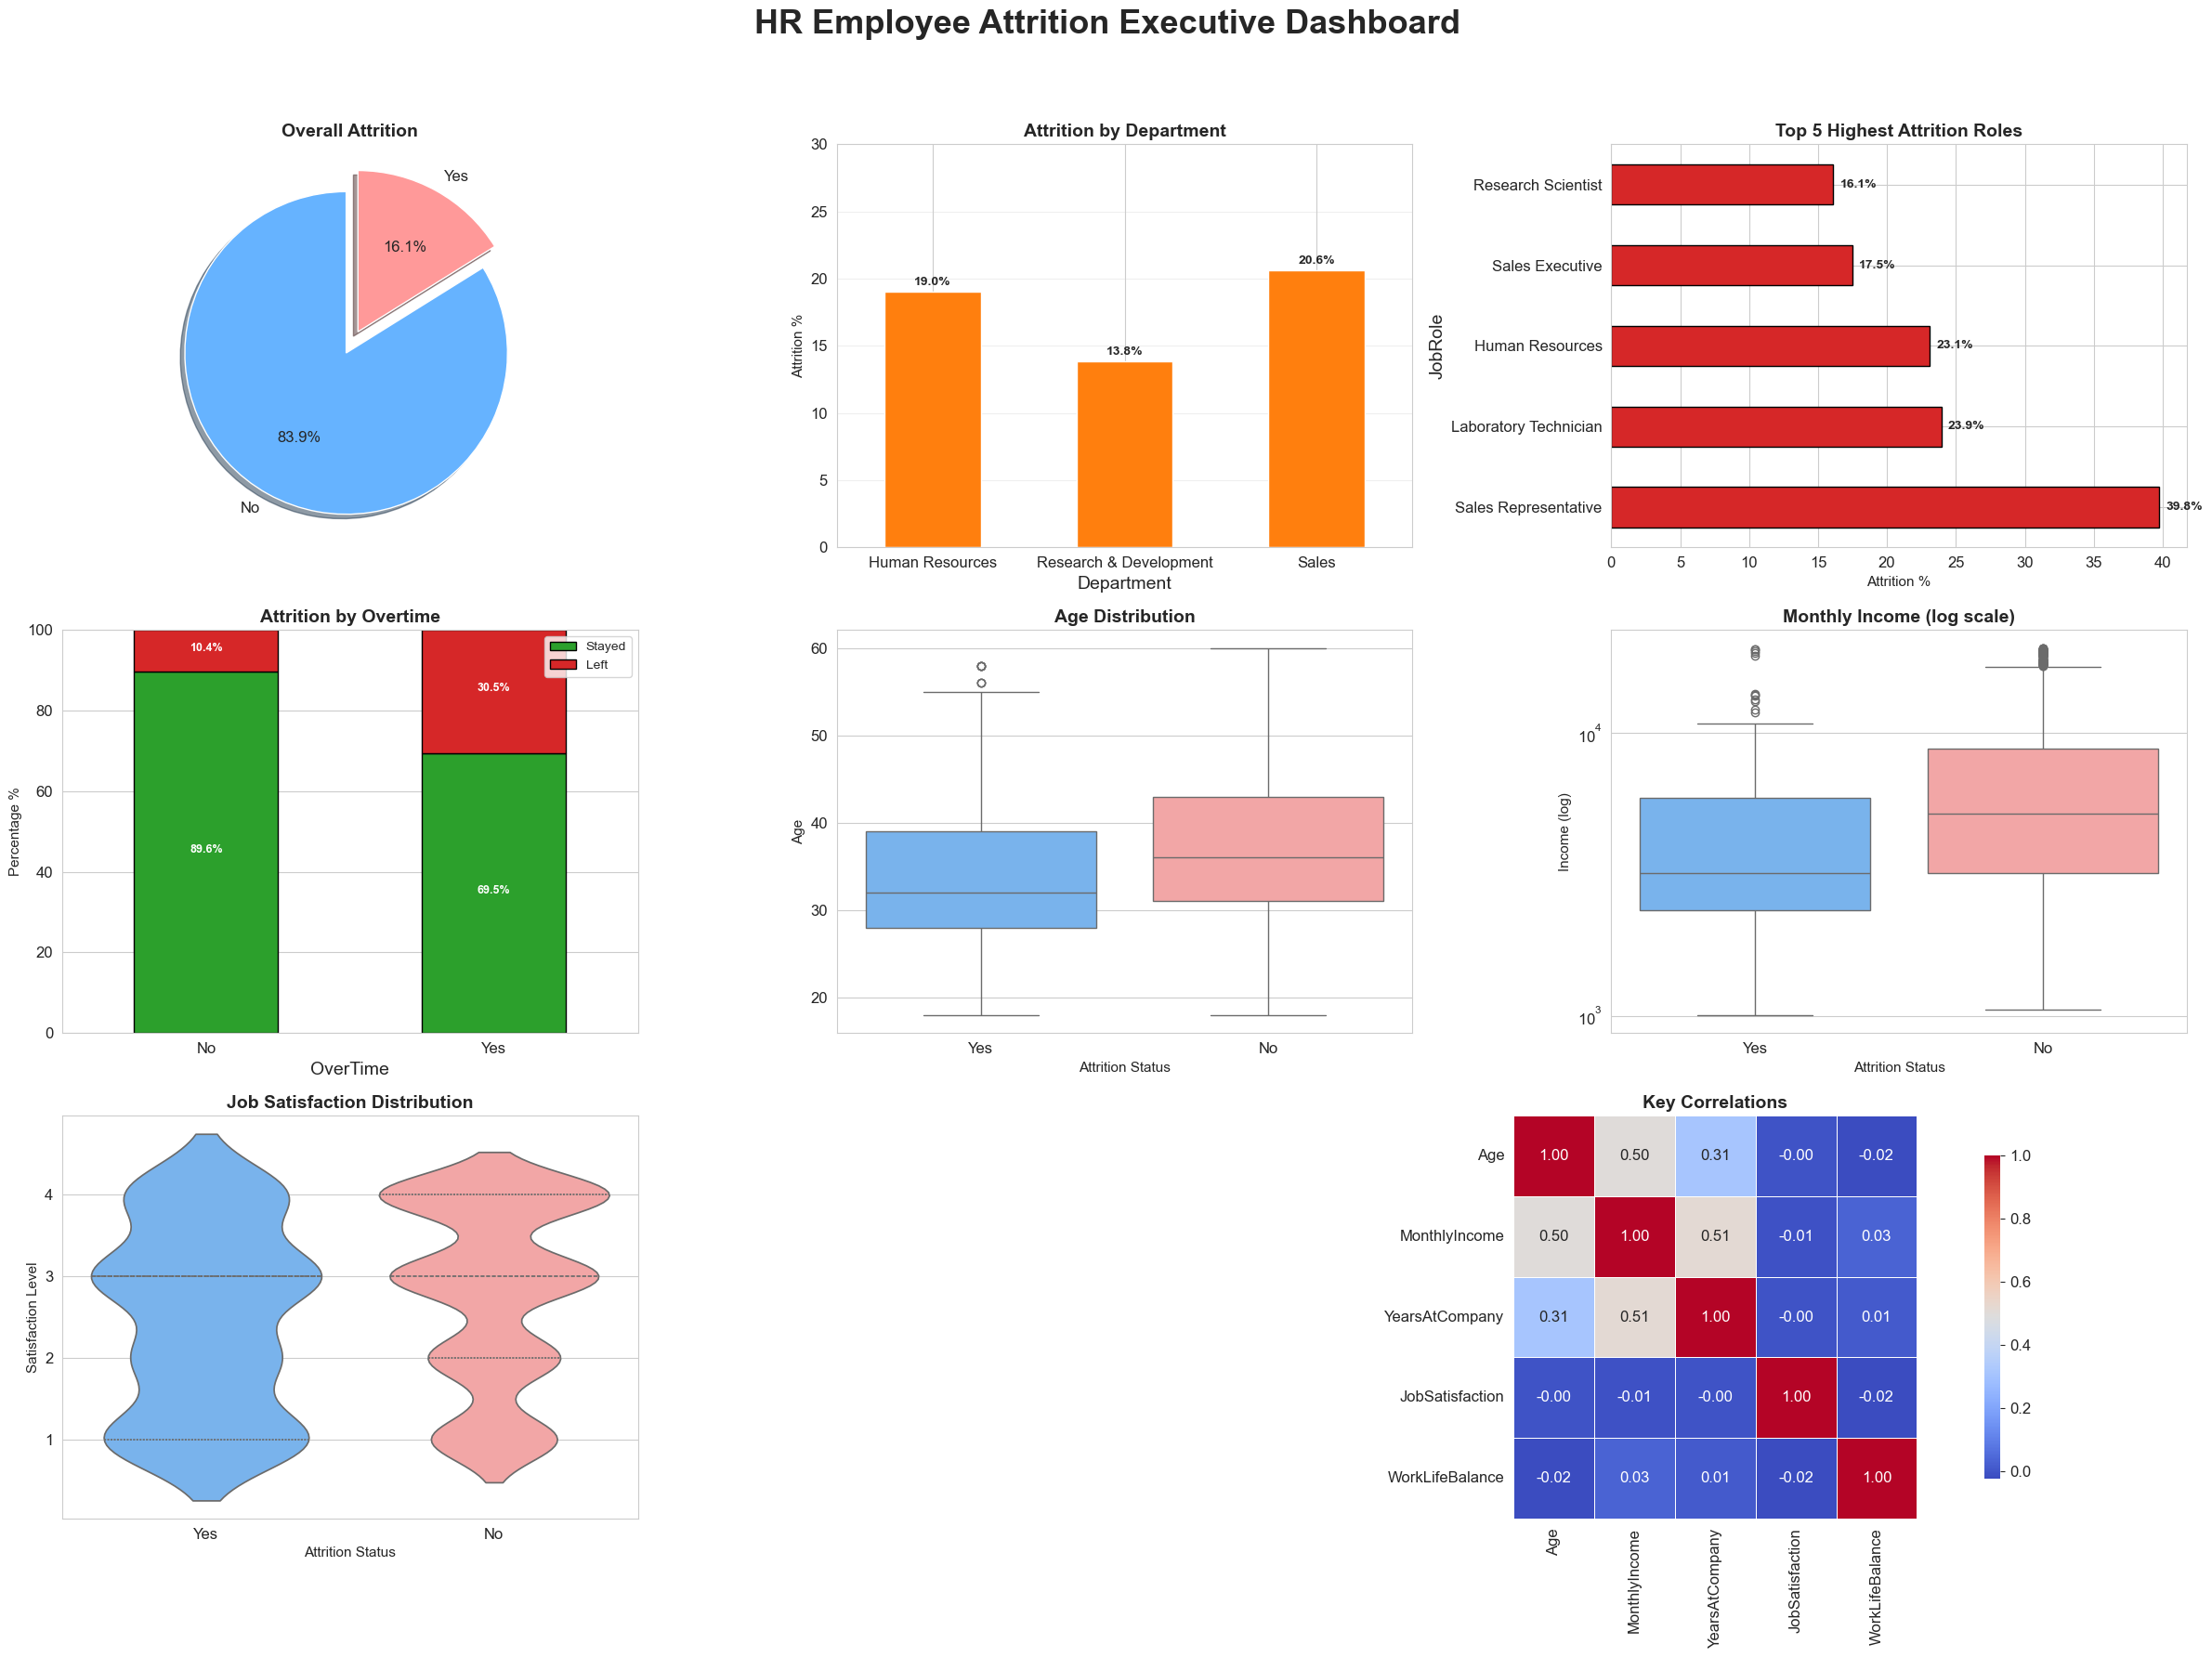

In [12]:
fig = plt.figure(figsize=(24, 18))
fig.suptitle('HR Employee Attrition Executive Dashboard', 
             fontsize=26, fontweight='bold', y=0.99)

ax1 = plt.subplot(3, 3, 1)
colors = ['#66b3ff', '#ff9999']
df['Attrition'].value_counts().plot.pie(autopct='%1.1f%%', colors=colors,
                                        explode=(0.05, 0.1), startangle=90, 
                                        shadow=True, ax=ax1)
ax1.set_title('Overall Attrition', fontsize=14, fontweight='bold')
ax1.set_ylabel('')

ax2 = plt.subplot(3, 3, 2)
dept_att = pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
dept_att['Yes'].plot(kind='bar', color='#ff7f0e', ax=ax2)
ax2.set_title('Attrition by Department', fontsize=14, fontweight='bold')
ax2.set_ylabel('Attrition %', fontsize=11)
ax2.set_ylim(0, 30)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
for i, v in enumerate(dept_att['Yes']):
    ax2.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

ax3 = plt.subplot(3, 3, 3)
job_att = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100
top5 = job_att['Yes'].sort_values(ascending=False).head(5)
top5.plot(kind='barh', color='#d62728', ax=ax3, edgecolor='black', linewidth=1)
ax3.set_title('Top 5 Highest Attrition Roles', fontsize=14, fontweight='bold')
ax3.set_xlabel('Attrition %', fontsize=11)
for i, v in enumerate(top5):
    ax3.text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold', fontsize=10)

ax4 = plt.subplot(3, 3, 4)
overtime_crosstab = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
overtime_crosstab.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'], 
                        ax=ax4, edgecolor='black', linewidth=1)
ax4.set_title('Attrition by Overtime', fontsize=14, fontweight='bold')
ax4.set_ylabel('Percentage %', fontsize=11)
ax4.set_ylim(0, 100)
ax4.legend(['Stayed', 'Left'], loc='upper right', fontsize=10)
for i in range(len(overtime_crosstab)):
    stayed_pct = overtime_crosstab.iloc[i, 0]
    left_pct = overtime_crosstab.iloc[i, 1]
    ax4.text(i, stayed_pct/2, f"{stayed_pct:.1f}%", ha='center', fontweight='bold', fontsize=9, color='white')
    ax4.text(i, stayed_pct + left_pct/2, f"{left_pct:.1f}%", ha='center', fontweight='bold', fontsize=9, color='white')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)

ax5 = plt.subplot(3, 3, 5)
sns.boxplot(x='Attrition', y='Age', data=df, ax=ax5, palette=['#66b3ff', '#ff9999'])
ax5.set_title('Age Distribution', fontsize=14, fontweight='bold')
ax5.set_xlabel('Attrition Status', fontsize=11)
ax5.set_ylabel('Age', fontsize=11)

ax6 = plt.subplot(3, 3, 6)
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, ax=ax6, palette=['#66b3ff', '#ff9999'])
ax6.set_title('Monthly Income (log scale)', fontsize=14, fontweight='bold')
ax6.set_xlabel('Attrition Status', fontsize=11)
ax6.set_ylabel('Income (log)', fontsize=11)
ax6.set_yscale('log')

ax7 = plt.subplot(3, 3, 7)
sns.violinplot(x='Attrition', y='JobSatisfaction', data=df, 
               palette=['#66b3ff', '#ff9999'], inner='quartile', ax=ax7)
ax7.set_title('Job Satisfaction Distribution', fontsize=14, fontweight='bold')
ax7.set_xlabel('Attrition Status', fontsize=11)
ax7.set_ylabel('Satisfaction Level', fontsize=11)

ax8 = plt.subplot(3, 3, (8, 9))
numeric_cols_small = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 'WorkLifeBalance']
corr_small = df[numeric_cols_small].corr()
sns.heatmap(corr_small, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}, ax=ax8)
ax8.set_title('Key Correlations', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('HR_Executive_Dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

# 📊 HR Attrition Data Story: Executive Summary

## The Problem

The company is experiencing a **16.12% employee attrition rate**, meaning approximately **1 in 6 employees** leave the organization. This rate is above industry average and requires immediate strategic intervention.

---

## Key Findings

### 1. High-Risk Departments and Roles
- **Sales department** has the highest attrition (20.6%), followed by **Human Resources** (19.1%)
- **Sales Representatives** are at critical risk with **39.8% attrition** — nearly 4 out of 10 leave
- Laboratory Technicians (23.9%) and HR staff (23.1%) also show concerning rates

### 2. Overtime is a Major Driver
- Employees working overtime are **3 times more likely** to leave (30.5% vs 10.4%)
- This suggests work-life balance issues or excessive workload

### 3. Employee Profile of Leavers
- **Younger** (average 33.6 years vs 37.6 years for stayers)
- **Lower income** (average $4,787 vs $6,833 — difference of ~$2,000)
- **Shorter tenure** (average 5.1 years vs 7.4 years)
- **Lower job satisfaction** scores

### 4. Satisfaction Matters
- Leavers consistently report lower job satisfaction
- Job satisfaction appears to be an independent factor not strongly correlated with other metrics

---

## Strategic Recommendations

| Priority | Action | Expected Impact |
|----------|--------|-----------------|
| **High** | Review compensation structure, especially for Sales and entry-level positions | Reduce income-driven attrition |
| **High** | Implement work-life balance programs and review overtime policies | Reduce overtime-related attrition |
| **Medium** | Create career development programs for younger employees | Improve early-career retention |
| **Medium** | Focus retention efforts on Sales Representatives and Laboratory Technicians | Address highest-risk roles |
| **Medium** | Regular satisfaction surveys with follow-up action plans | Early identification of at-risk employees |
| **Low** | Enhance onboarding and mentorship for new hires | Increase early tenure retention |

---

## Next Steps

1. **Immediate**: Conduct exit interviews with recent leavers to validate findings
2. **Short-term (1-3 months)**: Pilot work-life balance initiatives in Sales department
3. **Medium-term (3-6 months)**: Review and adjust compensation packages
4. **Long-term (6-12 months)**: Implement comprehensive retention strategy based on data insights

---

## Conclusion

The data clearly shows that **overtime, lower income, younger age, and specific job roles** are the most significant factors associated with employee attrition. By addressing these issues strategically, the company can significantly reduce turnover and improve employee satisfaction and retention.

---

*This analysis was prepared as part of a comprehensive HR analytics project using employee data from the company. All visualizations were created using Python (Matplotlib & Seaborn).*